In [1]:
import numpy as np

from scripts.functions import (get_reduced_exposures, get_reduced_spectra, coadd_fibers, plot_science_reduction_results, select_bright_fibers)
from scripts.telluric_correction import (query_star_properties, fit_telluric_star_model, fit_telluric_poly_model, apply_telluric_model, plot_star_telluric_model_fit, plot_poly_telluric_model_fit, plot_telluric_correction, windows_from_transmission)
from scripts.flux_calibration import (compute_throughput, save_throughput, plot_throughput_fit, plot_throughput_validation, plot_flux_calibration, load_throughput, plot_throughput, flux_calibrate_exposure, write_fluxcal_fits)

## Load reduced data for post-processing

In [2]:
# GALAXY and TELLURIC STANDARD observations

gal_and_tell_date = '20240701'
gal_and_tell_exposures = get_reduced_exposures(gal_and_tell_date, suffixes=('ssc', 'cf', 'a'))

# print out info for this observation
print('\nEXPOSURES:', end='\n\n')
print('file                           object      exposure time     GA        intermediate products')
for exp_id, exp in gal_and_tell_exposures.items():
    intermediate_data_products = [extension for extension in ('ssc', 'cf', 'a') if extension in exp]

    # save object grating angle
    if (exp['object'] != 'SKY') and (exp['object'] != 'ARC'):
        obj_GA = round(exp['grating_angle'],1)
        
    # print info on observation exposures
    print(f"{exp_id:28s} {exp['object']:15s}  {exp['exptime']:6.1f}        {obj_GA}      {intermediate_data_products}")
print('\nGRATING ANGLE:', obj_GA)

# # save diagnostic plots for the science reduction results
# plot_science_reduction_results(gal_and_tell_date)


EXPOSURES:

file                           object      exposure time     GA        intermediate products
dphN202407010002.2.1         J2114+0032        598.9        29.5      ['ssc', 'cf', 'a']
dphN202407010003.3.1         J2114+0032        598.9        29.5      ['ssc', 'cf', 'a']
dphN202407010004.4.1         J2114+0032        598.9        29.5      ['ssc', 'cf', 'a']
dphN202407010005.5.1         SKY               598.9        29.5      ['cf', 'a']
dphN202407010006.6.1         SKY                 1.5        29.5      []
dphN202407010006.6.2         SKY                 1.5        29.5      []
dphN202407010006.6.3         SKY                 1.5        29.5      []
dphN202407010006.6.4         SKY                 1.5        29.5      []
dphN202407010006.6.5         SKY                 1.5        29.5      []
dphN202407010007.7.1         ARC                 2.9        29.5      ['a']
dphN202407010008.8.1         ARC                 6.5        29.5      ['a']
dphN202407010009.9.1        

In [3]:
# SPEC-PHOT STANDARD observations

spec_phot_date = '20241015'
spec_phot_exposures = get_reduced_exposures(spec_phot_date, suffixes=('ssc', 'cf', 'a'))

# print out info for this observation
print('\nEXPOSURES:', end='\n\n')
print('file                           object      exposure time     GA        intermediate products')
for exp_id, exp in spec_phot_exposures.items():
    intermediate_data_products = [extension for extension in ('ssc', 'cf', 'a') if extension in exp]
    spec_phot_GA = round(exp['grating_angle'],1)

    # print info on observation exposures
    print(f"{exp_id:28s} {exp['object']:15s}  {exp['exptime']:6.1f}        {spec_phot_GA}      {intermediate_data_products}")
    
    # find the exposure with the same grating angle as object
    if (obj_GA == spec_phot_GA) and (exp['object'] != 'ARC') and (exp['object'] != 'SKY'):
        spec_phot_filename = exp_id
print(f'\nobservation with GA {obj_GA}:', spec_phot_filename)

# # save diagnostic plots for the science reduction results
# plot_science_reduction_results(spec_phot_date)


EXPOSURES:

file                           object      exposure time     GA        intermediate products
dphN202410150005.5.1         HD 19305           58.9        37.0      ['ssc', 'cf', 'a']
dphN202410150006.6.1         SKY                58.9        37.0      ['cf', 'a']
dphN202410150007.7.1         HD 19305           58.9        50.0      ['ssc', 'cf', 'a']
dphN202410150008.8.1         SKY                58.9        50.0      ['cf', 'a']
dphN202410150009.9.1         HD 19305           58.9        37.0      ['ssc', 'cf', 'a']
dphN202410150010.10.1        SKY                58.9        37.0      ['cf', 'a']
dphN202410150011.11.1        SKY                58.9        29.5      ['cf', 'a']
dphN202410150012.12.1        HD 19305           58.9        29.5      ['ssc', 'cf', 'a']
dphN202410150013.13.1        SKY                58.9        29.5      ['cf', 'a']
dphN202410150014.14.1        HD 19305           58.9        25.0      ['ssc', 'cf', 'a']
dphN202410150015.15.1        SKY       

In [4]:
# use above output to assign these variables
galaxy_name = 'J2114+0032'
telluric_standard_name = 'HIP 105164' # 'HIP 103889'
spec_phot_standard_name = 'HD 19305'

In [5]:
# identify galaxy, telluric standard, and spec-phot observation dictionaries
for exp_id, exp in gal_and_tell_exposures.items():
    if exp['object'] == telluric_standard_name:
        telluric_standard = exp
    elif exp['object'] == galaxy_name:   # NOTE: if dithered observation, this will save the last dither exposure. To reduce the rest, change this...
        galaxy = exp
for exp_id, exp in spec_phot_exposures.items():
    if exp_id == spec_phot_filename:
        spec_phot = exp

# save their spectra
gal_wave, gal_flux_all, gal_sigma_all, gal_gpcnt_wave, gal_gpcnt_data = get_reduced_spectra(galaxy, gal_and_tell_exposures)
tell_std_wave, tell_std_flux_all, tell_std_sigma_all, _ , _ = get_reduced_spectra(telluric_standard, gal_and_tell_exposures)  # gpcnt same as galaxy since same night of observation
spec_phot_wave, spec_phot_flux_all, spec_phot_sigma_all, spec_phot_gpcnt_wave, spec_phot_gpcnt_data  = get_reduced_spectra(spec_phot, spec_phot_exposures)

# Telluric correction

#### Fit telluric-standard observation with Pypeit stellar + telluric model

In [6]:
# star properties from SIMBAD
star_props = query_star_properties(telluric_standard_name)
print('stellar type:',star_props['sp_type'])
print('V mag:', round(star_props['v_mag'],2))

stellar type: B7III
V mag: 5.81


In [7]:
# select bright star fibers
star_fibers = select_bright_fibers(tell_std_flux_all, frac=0.01)
print('# of bright fibers:', len(star_fibers))

# co-add bright star fibers
telluric_flux, telluric_sigma = coadd_fibers(tell_std_flux_all, tell_std_sigma_all, star_fibers)

star_gpm = np.isfinite(telluric_flux) & np.isfinite(telluric_sigma) & (telluric_sigma > 0)
star_ivar = np.zeros_like(telluric_flux)
star_ivar[star_gpm] = 1.0 / telluric_sigma[star_gpm]**2
star_gpm &= np.isfinite(star_ivar) & (star_ivar < 1e40)   # drop inf ivar

 [WARNING] - 1143623262.py:<module>:11 - RuntimeWarning: overflow encountered in cast


# of bright fibers: 18


In [8]:
telluric_fit = fit_telluric_star_model(telluric_flux, tell_std_wave, star_ivar, star_gpm, star_props, 
                              telluric_standard['airmass'], telluric_standard['exptime'], polyorder=8)

tell_windows = windows_from_transmission(telluric_fit['transmission'], telluric_fit['wave'], threshold=0.98)
print('telluric windows from fit:', tell_windows)

    [INFO] - pypeitdata.py:get_file_path:300 - kurucz93/kp00/kp00_13000.fits.gz does not exist in the expected package directory (/opt/anaconda3/envs/pypeit/lib/python3.13/site-packages/pypeit/data/standards).  Checking cache or downloading the file now.
    [INFO] - flux_calib.py:get_mask:495 -  Masking bad pixels
    [INFO] - flux_calib.py:get_mask:500 -  Masking edges
    [INFO] - flux_calib.py:get_mask:503 -  Masking Below the atmospheric cutoff
    [INFO] - flux_calib.py:mask_stellar_hydrogen:585 - Masking hydrogen recombination lines
    [INFO] - flux_calib.py:mask_stellar_hydrogen:588 -  Masking Balmer
    [INFO] - flux_calib.py:mask_stellar_hydrogen:599 -  Masking Paschen
    [INFO] - flux_calib.py:mask_stellar_hydrogen:610 -  Masking Brackett
    [INFO] - flux_calib.py:mask_stellar_hydrogen:619 -  Masking Pfund
    [INFO] - telluric.py:__init__:2453 - Reading in the pca-based telluric model: TellPCA_3000_26000_R10000.fits
    [INFO] - pypeitdata.py:get_file_path:300 - TellPCA_

differential_evolution step 1: f(x)= 146214.8811812207
differential_evolution step 2: f(x)= 143691.85111416527
differential_evolution step 3: f(x)= 143691.85111416527
differential_evolution step 4: f(x)= 127779.51932810097
differential_evolution step 5: f(x)= 114573.84547574678
differential_evolution step 6: f(x)= 108166.45863071151
differential_evolution step 7: f(x)= 108166.45863071151
differential_evolution step 8: f(x)= 108166.45863071151
differential_evolution step 9: f(x)= 108166.45863071151
differential_evolution step 10: f(x)= 91665.21534619454
differential_evolution step 11: f(x)= 87904.40799785416
differential_evolution step 12: f(x)= 87904.40799785416
differential_evolution step 13: f(x)= 87904.40799785416
differential_evolution step 14: f(x)= 87904.40799785416
differential_evolution step 15: f(x)= 87904.40799785416
differential_evolution step 16: f(x)= 87904.40799785416
differential_evolution step 17: f(x)= 86081.28992380781
differential_evolution step 18: f(x)= 80462.12863

 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.3153522043237607 < 1.
Errors are overestimated so not applying correction.


differential_evolution step 1: f(x)= 342.7651636450166
differential_evolution step 2: f(x)= 340.3111111796993
differential_evolution step 3: f(x)= 340.3111111796993
differential_evolution step 4: f(x)= 340.3111111796993
differential_evolution step 5: f(x)= 337.53759861450783
differential_evolution step 6: f(x)= 335.45743338916805
differential_evolution step 7: f(x)= 334.66572170905306
differential_evolution step 8: f(x)= 332.8353233043326
differential_evolution step 9: f(x)= 331.5456637874752
differential_evolution step 10: f(x)= 331.5456637874752
differential_evolution step 11: f(x)= 331.00252988142483
differential_evolution step 12: f(x)= 328.2679948149985
differential_evolution step 13: f(x)= 328.2679948149985
differential_evolution step 14: f(x)= 328.2679948149985
differential_evolution step 15: f(x)= 328.2679948149985
differential_evolution step 16: f(x)= 328.2679948149985
differential_evolution step 17: f(x)= 328.2679948149985
differential_evolution step 18: f(x)= 328.26799481499

 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.3160458357456108 < 1.
Errors are overestimated so not applying correction.


differential_evolution step 1: f(x)= 334.1500106555718
differential_evolution step 2: f(x)= 330.3530898254912
differential_evolution step 3: f(x)= 330.3530898254912
differential_evolution step 4: f(x)= 329.6613614325878
differential_evolution step 5: f(x)= 329.6613614325878
differential_evolution step 6: f(x)= 329.6613614325878
differential_evolution step 7: f(x)= 329.6613614325878
differential_evolution step 8: f(x)= 329.6613614325878
differential_evolution step 9: f(x)= 329.6613614325878
differential_evolution step 10: f(x)= 329.17865093200805
differential_evolution step 11: f(x)= 326.6086698400784
differential_evolution step 12: f(x)= 326.6086698400784
differential_evolution step 13: f(x)= 325.86290243979374
differential_evolution step 14: f(x)= 324.5474797581665
differential_evolution step 15: f(x)= 324.2099498788759
differential_evolution step 16: f(x)= 324.2099498788759
Polishing solution with 'L-BFGS-B'


 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.3160907439996326 < 1.
Errors are overestimated so not applying correction.
 [WARNING] - fitting.py:robust_optimize:626 - Maximum number of iterations maxiter=3 reached in robust_optimize


  SUCCESS=True  CHI2=323.1  R=2778  shift=-1.00  stretch=1.0004
telluric windows from fit: [(9536.82100057, 9676.42881361), (9680.18171181, 9707.20257885), (9710.20489741, 9720.71301237), (9723.715330930001, 9771.75242789), (9774.75474645, 9807.78025061), (9815.28604701, 9820.54010449), (9825.04358233, 9831.04821945), (10859.34232625, 10865.34696337), (10901.37478609, 10906.62884357), (10923.14159565, 10929.89681241), (10945.65898485, 10950.913042330001), (10956.16709981, 10964.42347585), (10974.93159081, 10982.43738721), (10984.68912613, 11013.21115245), (11015.46289137, 11125.79809845)]


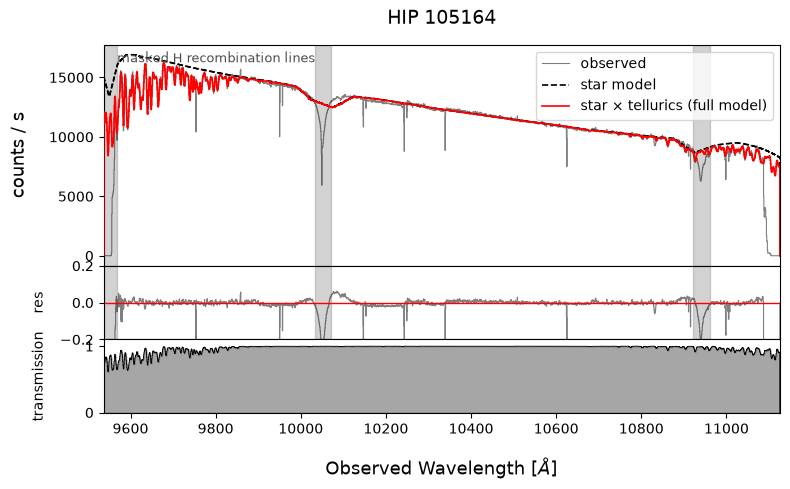

In [9]:
plot_star_telluric_model_fit(tell_std_wave, telluric_flux, telluric_fit, obj_dict=telluric_standard)

#### Apply correction to galaxy observation

In [10]:
# select bright galaxy fibers
gal_fibers = select_bright_fibers(gal_flux_all, frac=0.2)  # 0.2 for 20240701, 0.18 for 20240725 ... need to standardize this better?
print('# of bright fibers:', len(gal_fibers))

# of bright fibers: 15


In [11]:
# co-add bright star fibers
gal_coadd, gal_sigma_coadd = coadd_fibers(gal_flux_all, gal_sigma_all, gal_fibers)
gal_gpcnt_arr = np.nansum(gal_gpcnt_data[gal_fibers], axis=0)

In [12]:
gal_flux_tcorr = apply_telluric_model(gal_coadd, gal_sigma_coadd, gal_wave, telluric_fit['transmission'], telluric_fit['wave'])

 [WARNING] - telluric_correction.py:plot_telluric_correction:433 - RuntimeWarning: invalid value encountered in divide
    [INFO] - pypeitdata.py:get_file_path:300 - TellPCA_3000_26000_R10000.fits does not exist in the expected package directory (/opt/anaconda3/envs/pypeit/lib/python3.13/site-packages/pypeit/data/telluric/atm_grids).  Checking cache or downloading the file now.
 [WARNING] - cache.py:fetch_remote_file:242 - Note: If this file takes a while to download, you may wish to used one of the install scripts (e.g., pypeit_install_telluric) to install the file independent of this processing script.


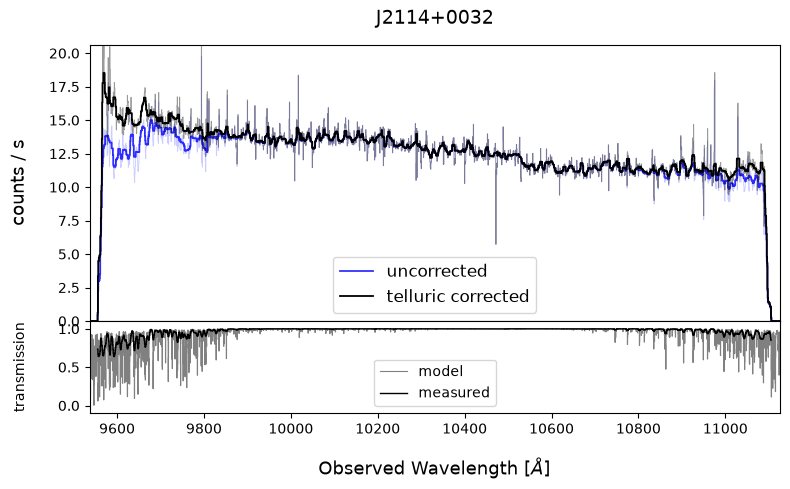

In [13]:
plot_telluric_correction(gal_wave, gal_coadd, gal_flux_tcorr['flux'], obj_dict=galaxy)

#### Fit spectro-photometric standard observation with Pypeit poly + telluric model

In [14]:
# select bright star fibers
spec_phot_star_fibers = select_bright_fibers(spec_phot_flux_all, frac=0.01)
print('# of bright fibers:', len(spec_phot_star_fibers))

# co-add bright star fibers
spec_phot_flux, spec_phot_sigma = coadd_fibers(spec_phot_flux_all, spec_phot_sigma_all, spec_phot_star_fibers)

star_gpm = np.isfinite(spec_phot_flux) & np.isfinite(spec_phot_sigma) & (spec_phot_sigma > 0)
star_ivar = np.zeros_like(spec_phot_flux)
star_ivar[star_gpm] = 1.0 / spec_phot_sigma[star_gpm]**2
star_gpm &= np.isfinite(star_ivar) & (star_ivar < 1e40)   # drop inf ivar

 [WARNING] - 4071279955.py:<module>:11 - RuntimeWarning: overflow encountered in cast


# of bright fibers: 22


In [15]:
spec_phot_fit = fit_telluric_poly_model(spec_phot_flux, spec_phot_wave, star_ivar, star_gpm, 
                                        spec_phot['airmass'], spec_phot['exptime'], polyorder=3)  # 20240701: polyorder=3, 20240725: polyorder=12

tell_windows = windows_from_transmission(spec_phot_fit['transmission'], spec_phot_fit['wave'], threshold=0.98)
print('telluric windows from fit:', tell_windows)

    [INFO] - flux_calib.py:get_mask:495 -  Masking bad pixels
    [INFO] - flux_calib.py:get_mask:500 -  Masking edges
    [INFO] - flux_calib.py:get_mask:503 -  Masking Below the atmospheric cutoff
    [INFO] - flux_calib.py:mask_stellar_hydrogen:585 - Masking hydrogen recombination lines
    [INFO] - flux_calib.py:mask_stellar_hydrogen:588 -  Masking Balmer
    [INFO] - flux_calib.py:mask_stellar_hydrogen:599 -  Masking Paschen
    [INFO] - flux_calib.py:mask_stellar_hydrogen:610 -  Masking Brackett
    [INFO] - flux_calib.py:mask_stellar_hydrogen:619 -  Masking Pfund
    [INFO] - telluric.py:__init__:2453 - Reading in the pca-based telluric model: TellPCA_3000_26000_R10000.fits
    [INFO] - pypeitdata.py:get_file_path:300 - TellPCA_3000_26000_R10000.fits does not exist in the expected package directory (/opt/anaconda3/envs/pypeit/lib/python3.13/site-packages/pypeit/data/telluric/atm_grids).  Checking cache or downloading the file now.
 [WARNING] - cache.py:fetch_remote_file:242 - No

differential_evolution step 1: f(x)= 140491.26568122295
differential_evolution step 2: f(x)= 131224.9658456993
differential_evolution step 3: f(x)= 111748.15428968513
differential_evolution step 4: f(x)= 111748.15428968513
differential_evolution step 5: f(x)= 111748.15428968513
differential_evolution step 6: f(x)= 86719.13566196598
differential_evolution step 7: f(x)= 86719.13566196598
differential_evolution step 8: f(x)= 86719.13566196598
differential_evolution step 9: f(x)= 73593.9710932018
differential_evolution step 10: f(x)= 65857.2152630132
differential_evolution step 11: f(x)= 65857.2152630132
differential_evolution step 12: f(x)= 48996.49270252492
differential_evolution step 13: f(x)= 48996.49270252492
differential_evolution step 14: f(x)= 48996.49270252492
differential_evolution step 15: f(x)= 48996.49270252492
differential_evolution step 16: f(x)= 48996.49270252492
differential_evolution step 17: f(x)= 30292.235490884115
differential_evolution step 18: f(x)= 30292.23549088411

 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.5130906089544367 < 1.
Errors are overestimated so not applying correction.


differential_evolution step 115: f(x)= 1280.616927349812
Polishing solution with 'L-BFGS-B'
differential_evolution step 1: f(x)= 720.7753798194908
differential_evolution step 2: f(x)= 710.2715659085807
differential_evolution step 3: f(x)= 710.2715659085807
differential_evolution step 4: f(x)= 710.2715659085807
differential_evolution step 5: f(x)= 710.2715659085807
differential_evolution step 6: f(x)= 709.4952524103384
differential_evolution step 7: f(x)= 709.4952524103384
differential_evolution step 8: f(x)= 709.4952524103384
differential_evolution step 9: f(x)= 708.2961504193863
differential_evolution step 10: f(x)= 708.2589691889979
differential_evolution step 11: f(x)= 708.2589691889979
differential_evolution step 12: f(x)= 708.1333282552895
Polishing solution with 'L-BFGS-B'


 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.4833252700026837 < 1.
Errors are overestimated so not applying correction.


differential_evolution step 1: f(x)= 703.6034032223471
differential_evolution step 2: f(x)= 697.3692206365806
differential_evolution step 3: f(x)= 697.3692206365806
differential_evolution step 4: f(x)= 696.6525267270353
differential_evolution step 5: f(x)= 696.4097615234591
differential_evolution step 6: f(x)= 695.8619187797849
differential_evolution step 7: f(x)= 695.3859447787179
differential_evolution step 8: f(x)= 695.3859447787179
differential_evolution step 9: f(x)= 695.3859447787179


 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.4809714178950314 < 1.
Errors are overestimated so not applying correction.
 [WARNING] - fitting.py:robust_optimize:626 - Maximum number of iterations maxiter=3 reached in robust_optimize


differential_evolution step 10: f(x)= 694.9534776398068
Polishing solution with 'L-BFGS-B'
differential_evolution step 1: f(x)= 693.2828678759852
differential_evolution step 2: f(x)= 693.2828678759852
differential_evolution step 3: f(x)= 693.2828678759852
differential_evolution step 4: f(x)= 693.2828678759852
differential_evolution step 5: f(x)= 693.2828678759852
differential_evolution step 6: f(x)= 692.6547198860196
differential_evolution step 7: f(x)= 692.6547198860196
differential_evolution step 8: f(x)= 692.120253728877
differential_evolution step 9: f(x)= 692.120253728877
differential_evolution step 10: f(x)= 692.120253728877
differential_evolution step 11: f(x)= 691.621746156603
differential_evolution step 12: f(x)= 691.621746156603
Polishing solution with 'L-BFGS-B'


 [WARNING] - coadd.py:renormalize_errors:120 - Error renormalization found correction factor sigma_corr = 0.4808568235683418 < 1.
Errors are overestimated so not applying correction.


  SUCCESS=True  CHI2=690.9  R=3195  shift=-0.39  stretch=1.0002
telluric windows from fit: [(9536.79192434, 9676.43632358), (9680.19020528, 9720.73212764), (9722.984456659999, 9808.572959419998), (9813.828393799999, 9831.096249619999), (9843.8594474, 9854.370316159999), (10858.909059079999, 10865.666046139999), (10890.441665359998, 10896.44787608), (10900.952534119999, 10907.709521179999), (10923.47582432, 10930.23281138), (10944.497561839999, 10952.00532524), (10955.75920694, 10964.768523019999), (10973.7778391, 11013.568985119999), (11015.070537799998, 11126.185436119998)]


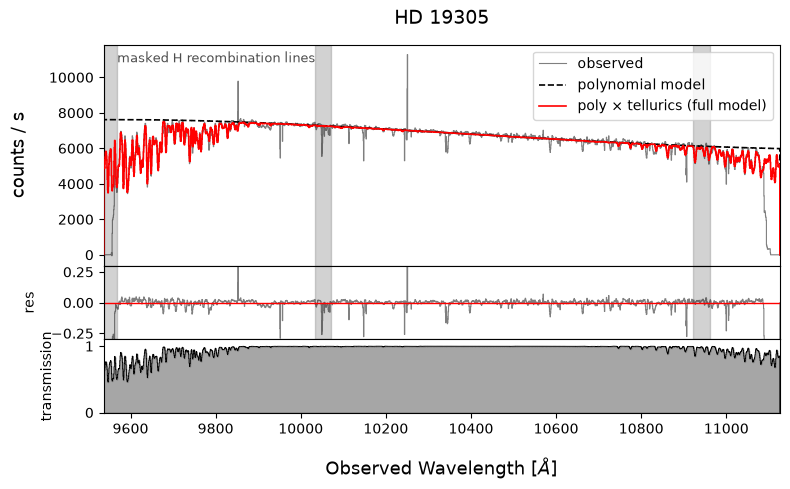

In [16]:
plot_poly_telluric_model_fit(spec_phot_wave, spec_phot_flux, spec_phot_fit, obj_dict=spec_phot)

#### Apply correction to spec-phot observation

In [17]:
# select bright galaxy fibers
spec_phot_fibers = select_bright_fibers(spec_phot_flux_all, frac=0.01)
print('# of bright fibers:', len(spec_phot_fibers))

# of bright fibers: 22


In [18]:
# co-add bright star fibers
spec_phot_coadd, spec_phot_sigma_coadd = coadd_fibers(spec_phot_flux_all, spec_phot_sigma_all, spec_phot_fibers)
spec_phot_gpcnt_arr = np.nansum(spec_phot_gpcnt_data[spec_phot_fibers], axis=0)

In [19]:
spec_phot_flux_tcorr = apply_telluric_model(spec_phot_coadd, spec_phot_sigma_coadd, spec_phot_wave, spec_phot_fit['transmission'], spec_phot_fit['wave'])

 [WARNING] - telluric_correction.py:plot_telluric_correction:433 - RuntimeWarning: invalid value encountered in divide
    [INFO] - pypeitdata.py:get_file_path:300 - TellPCA_3000_26000_R10000.fits does not exist in the expected package directory (/opt/anaconda3/envs/pypeit/lib/python3.13/site-packages/pypeit/data/telluric/atm_grids).  Checking cache or downloading the file now.
 [WARNING] - cache.py:fetch_remote_file:242 - Note: If this file takes a while to download, you may wish to used one of the install scripts (e.g., pypeit_install_telluric) to install the file independent of this processing script.


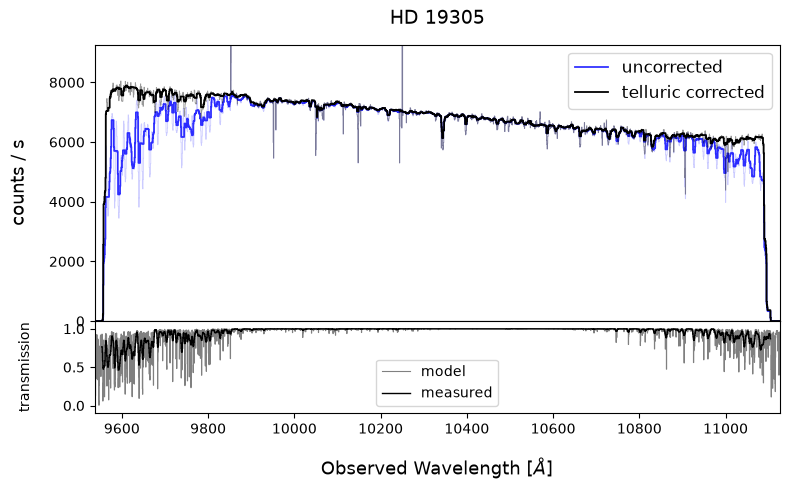

In [20]:
plot_telluric_correction(spec_phot_wave, spec_phot_coadd, spec_phot_flux_tcorr['flux'], obj_dict=spec_phot)

In [21]:
# update flux in dictionary with telluric-corrected flux !
res = apply_telluric_model(np.asarray(spec_phot['flux'], dtype=float), np.asarray(spec_phot_sigma_all, dtype=float), spec_phot_wave, spec_phot_fit['transmission'], spec_phot_fit['wave'])
spec_phot['flux'][:] = res['flux'].astype(spec_phot['flux'].dtype)

# Flux calibration

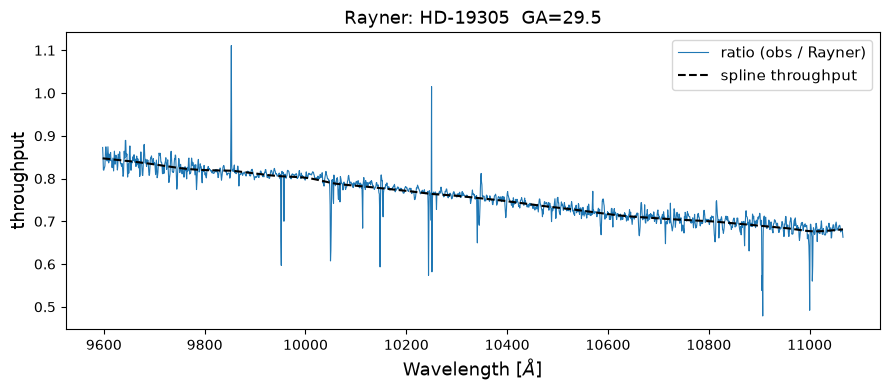

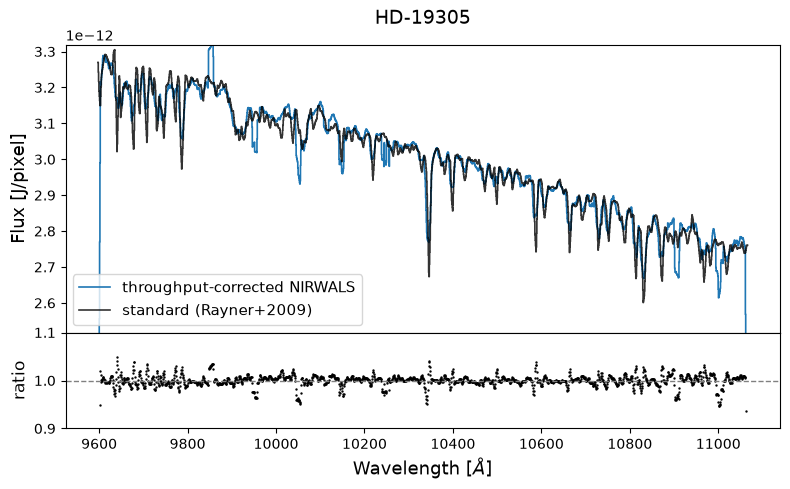

wrote throughput curve: /Users/MarissaPerry/Documents/PhD/projects/packages/NIRWALS_reduction/post_reduction_processing/outputs/throughput_curves/HD-19305_GA295_throughput.csv


In [22]:
# compute the throughput curve from the Rayner standard
throughput_result = compute_throughput(spec_phot_obs=spec_phot, spec_phot_name=spec_phot_standard_name, tell_windows=None) #tell_windows=tell_windows)
plot_throughput_fit(throughput_result, obj_dict=spec_phot)
plot_throughput_validation(throughput_result, obj_dict=spec_phot)
throughput_file = save_throughput(throughput_result)

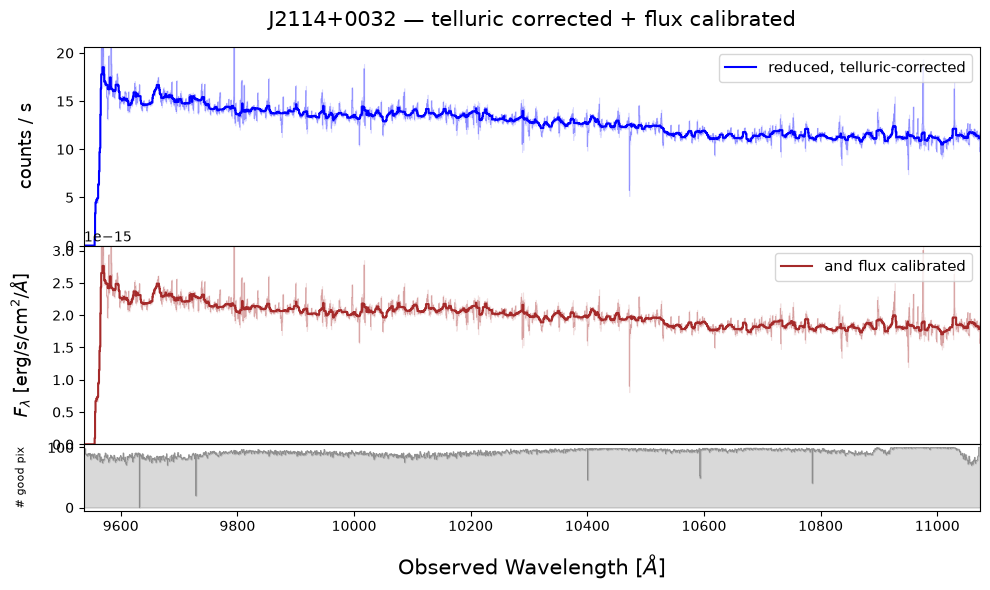

In [23]:
# flux-calibrate the telluric-corrected galaxy
F, F_err = flux_calibrate_exposure(gal_wave, gal_flux_tcorr['flux'], gal_flux_tcorr['sigma'], galaxy, throughput_file)
plot_flux_calibration(gal_wave, gal_flux_tcorr['flux'], gal_flux_tcorr['sigma'], F, F_err, gal_gpcnt_wave, gal_gpcnt_arr, 
                      obj_dict=galaxy, title=f"{galaxy_name} — telluric corrected + flux calibrated")

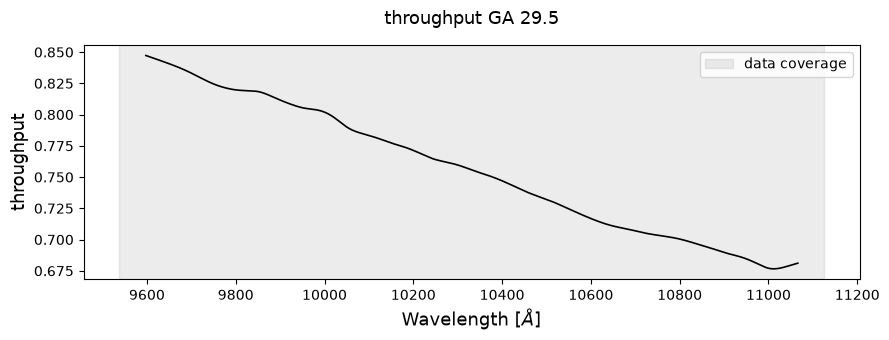

In [24]:
twave, tvalue = load_throughput(throughput_file)
plot_throughput(twave, tvalue, wave_range=(gal_wave.min(), gal_wave.max()), tell_windows=None, title=f"throughput GA {obj_GA}")

In [25]:
ssc_file = galaxy['ssc']['file']
out_file = ssc_file.replace('ssc.fits', 'tellcorr_fluxcal.fits')

write_fluxcal_fits(
    template_file=ssc_file,
    wave=gal_wave, 
    flux=F, sigma=F_err,
    out_file=out_file, 
    throughput_file=throughput_file
)
print('wrote', out_file)

wrote /Users/MarissaPerry/Documents/PhD/projects/packages/NIRWALS_reduction/nirwals_pipeline/20240701/JUNK/product/dphN202407010004.4.1.reduced.tellcorr_fluxcal.fits
